# MLP for Asset Category Prediction

**Goal**: Predict asset server-function categories using:
- **Ports** (one-hot for top ports + count features)
- **Banners** (Server header, HTTP status, Content-Type — static parts only)
- **Domain Name** (tokenized TF-IDF)
- **Technologies** (one-hot encoded)
- **Passive DNS Query Count** (log-normalized)
    
**Data**: `asset_2.csv` — 75,529 assets, 263 raw categories consolidated to ~20 canonical categories

## Step 1: Imports

In [49]:
import pandas as pd
import numpy as np
import re
import json
import warnings
warnings.filterwarnings('ignore')

from collections import Counter, defaultdict
from pprint import pprint

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import f1_score, accuracy_score, hamming_loss, classification_report
from scipy.sparse import hstack, csr_matrix

import matplotlib.pyplot as plt
import seaborn as sns

print("All imports loaded ✅")

All imports loaded ✅


## Step 2: Load & Parse Data
Parse the postgres array formats for ports, categories. Extract technology names from JSON. Parse passive DNS count.

In [50]:
# ── Load CSV ──
df = pd.read_csv('asset_2.csv', low_memory=False)
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols")

# ── Parse postgres array → list:  {80,443} → [80, 443] ──
def parse_pg_array(val):
    """Parse postgres array like {80,443} into a list of strings."""
    if pd.isna(val) or str(val).strip() in ('', '{}', 'NULL'):
        return []
    s = str(val).strip().strip('{}')
    if not s:
        return []
    return [x.strip().strip('"') for x in s.split(',') if x.strip()]

# ── Parse categories:  {"web server","api endpoint"} → ['web server', 'api endpoint'] ──
def parse_categories(val):
    """Parse postgres text-array with quoted items."""
    if pd.isna(val) or str(val).strip() in ('', '{}', 'NULL'):
        return []
    s = str(val).strip()
    # Find quoted items
    items = re.findall(r'"([^"]+)"', s)
    if items:
        return [i.strip().lower() for i in items]
    # Fallback: simple comma-split (unquoted)
    s = s.strip('{}')
    return [i.strip().lower() for i in s.split(',') if i.strip()]

# ── Parse technologies JSON: [{"name":"AkamaiGHost"}] → ['AkamaiGHost'] ──
def parse_technologies(val):
    if pd.isna(val) or str(val).strip() in ('', '{}', 'NULL', '[]'):
        return []
    try:
        items = json.loads(str(val))
        if isinstance(items, list):
            return [d.get('name', '') for d in items if isinstance(d, dict) and d.get('name')]
        return []
    except (json.JSONDecodeError, TypeError):
        return []

# ── Apply parsers ──
df['ports_list']   = df['ports'].apply(parse_pg_array)
df['cats_list']    = df['categories'].apply(parse_categories)
df['tech_list']    = df['technologies'].apply(parse_technologies)
df['dns_count']    = pd.to_numeric(df['passive_dns_query_count'], errors='coerce').fillna(0).astype(int)

# ── Quick stats ──
has_ports = df['ports_list'].apply(len).gt(0).sum()
has_cats  = df['cats_list'].apply(len).gt(0).sum()
has_tech  = df['tech_list'].apply(len).gt(0).sum()
has_dns   = df['dns_count'].gt(0).sum()
has_banner= df['banners'].notna().sum()

print(f"\n{'Feature':<25} {'Rows with data':>15}")
print("-" * 42)
for label, cnt in [('Ports', has_ports), ('Categories (target)', has_cats),
                   ('Technologies', has_tech), ('Passive DNS > 0', has_dns),
                   ('Banners', has_banner), ('Domain Name', df['domain_name'].notna().sum())]:
    print(f"{label:<25} {cnt:>15,}")

# ── Peek unique categories ──
all_cats = [c for cats in df['cats_list'] for c in cats]
print(f"\nTotal category assignments: {len(all_cats):,}")
print(f"Unique raw categories:     {len(set(all_cats))}")
print(f"\nTop 20 categories:")
for cat, cnt in Counter(all_cats).most_common(20):
    print(f"  {cat:<40} {cnt:>6,}")

Loaded: 75,529 rows × 27 cols

Feature                    Rows with data
------------------------------------------
Ports                              26,946
Categories (target)                70,861
Technologies                       12,416
Passive DNS > 0                    62,356
Banners                            75,529
Domain Name                        75,465

Total category assignments: 107,749
Unique raw categories:     271

Top 20 categories:
  unknown                                  33,157
  web server                               15,074
  content delivery network                  9,930
  content delivery service                  7,068
  reverse proxy                             5,503
  api endpoint                              5,369
  http service                              3,896
  cloud service                             3,414
  push notification service                 2,239
  cdn service                               2,082
  https service                             

## Step 3: Banner Cleaning
Extract only the **static** parts from banners (Server header, HTTP status code, Content-Type).  
Discard dynamic noise: Date, Set-Cookie, Content-Length, CF-RAY, etc.

In [51]:
def extract_banner_features(banner_raw):
    """Extract static, informative parts from a raw HTTP banner string."""
    if pd.isna(banner_raw) or str(banner_raw).strip() in ('', '{}'):
        return {'server': '', 'status_code': '', 'content_type': ''}
    
    text = str(banner_raw)
    
    # Server header  (e.g.  Server: AkamaiGHost)
    m = re.search(r'Server:\s*([^\r\n"\\]+)', text, re.IGNORECASE)
    server = m.group(1).strip().lower() if m else ''
    
    # HTTP status code  (e.g.  HTTP/1.1 301)
    m = re.search(r'HTTP/[\d.]+\s+(\d{3})', text)
    status = m.group(1) if m else ''
    
    # Content-Type  (e.g.  Content-Type: text/html)
    m = re.search(r'Content-Type:\s*([^\r\n";\\]+)', text, re.IGNORECASE)
    ctype = m.group(1).strip().lower() if m else ''
    
    return {'server': server, 'status_code': status, 'content_type': ctype}

# ── Apply to all rows ──
banner_feats = df['banners'].apply(extract_banner_features).apply(pd.Series)
df['banner_server']  = banner_feats['server']
df['banner_status']  = banner_feats['status_code']
df['banner_ctype']   = banner_feats['content_type']

# ── Stats ──
print("=== Banner Feature Extraction ===\n")
for col in ['banner_server', 'banner_status', 'banner_ctype']:
    non_empty = (df[col] != '').sum()
    unique    = df[col][df[col] != ''].nunique()
    print(f"{col:<20}  filled: {non_empty:>7,}   unique: {unique:>5}")

print(f"\n--- Top 15 Server headers ---")
for val, cnt in Counter(df['banner_server'][df['banner_server'] != '']).most_common(15):
    print(f"  {val:<45} {cnt:>6,}")

print(f"\n--- HTTP Status Codes ---")
for val, cnt in Counter(df['banner_status'][df['banner_status'] != '']).most_common(10):
    print(f"  {val:<10} {cnt:>6,}")

print(f"\n--- Top 10 Content-Types ---")
for val, cnt in Counter(df['banner_ctype'][df['banner_ctype'] != '']).most_common(10):
    print(f"  {val:<45} {cnt:>6,}")

=== Banner Feature Extraction ===

banner_server         filled:  22,279   unique:    85
banner_status         filled:  26,447   unique:    20
banner_ctype          filled:  24,830   unique:     7

--- Top 15 Server headers ---
  akamaighost                                    9,035
  apple                                          5,925
  applehttpserver/a3fb6e96e80a                   1,546
  cloudfront                                     1,464
  hex                                            1,445
  awselb/2.0                                       322
  applehttpserver/2caa77a6bc2e755fca0e0f63e4d67e53390f9184    241
  varnish                                          235
  nginx                                            222
  apache                                           213
  cloudflare                                       204
  kngx/1.10.2                                      185
  istio-envoy                                      124
  daiquiri/5                                  

## Step 4: Consolidate Categories (271 → ~20)
Many categories are synonymous (e.g. "content delivery network" ↔ "content delivery service" ↔ "cdn service").  
Map them to ~20 canonical labels for a cleaner, more learnable target.

In [52]:
# ── Category consolidation map ──
# Keys: 49 canonical categories provided by the user.
# Values: list of raw labels from asset_2.csv that map to each.
CATEGORY_MAP = {
    # 1
    'web server': [
        'web server', 'http server', 'https server', 'http service',
        'https service', 'secure web server', 'web service',
        'secure web service', 'web application', 'secure web application',
        'web hosting', 'web hosting service', 'web platform',
        'web application server', 'front end service', 'frontend service',
        'http gateway', 'http endpoint', 'https endpoint',
        'static content hosting', 'redirecting service', 'redirect service',
        'secure server', 'staging environment', 'download server',
        'dashboard service', 'development server', 'portal service',
        'e-commerce platform', 'website', 'redirect server',
        'redirection service', 'stage environment', 'testing environment',
        'ecommerce platform', 'stage service', 'site hosting service',
        'e-commerce service', 'ecommerce service', 'hosting service',
        'website redirection', 'www service', 'secured web service',
        'test environment', 'forum server', 'discussion platform',
        'service portal', 'captive portal', 'web endpoint',
        'checkout service', 'forbidden access service',
    ],
    # 2
    'content delivery network': [
        'content delivery network', 'content delivery service', 'cdn service',
        'cdn', 'cdn endpoint', 'content distribution', 'edge server',
        'edge service', 'edge cache', 'edge node', 'content caching',
        'caching service', 'cache server', 'caching proxy',
        'content storage service', 'cache service', 'caching server',
        'content caching service', 'cds service', 'blocking service',
    ],
    # 3
    'reverse proxy': [
        'reverse proxy', 'reverse proxy server', 'proxy server',
        'proxy service', 'traffic manager', 'traffic management',
        'application delivery controller', 'service mesh',
        'gateway', 'gateway service', 'forwarding service',
        'ingress service', 'ssl termination service',
        'relay server', 'traffic mirroring service',
    ],
    # 4
    'load balancer': [
        'load balancer', 'load balancing service',
    ],
    # 5
    'vpn server': [
        'vpn server', 'vpn service', 'vpn gateway', 'vpn endpoint',
        'ssl vpn', 'ipsec vpn', 'secure connection service',
        'secure access server',
    ],
    # 6
    'firewall': [
        'firewall', 'web application firewall', 'waf',
        'ddos protection', 'threat protection',
        'security service', 'security server', 'security gateway',
        'security appliance', 'security platform', 'security device',
        'ids', 'ips',
        'administrative interface', 'admin panel', 'access control',
        'administrative server',
    ],
    # 7
    'api endpoint': [
        'api endpoint', 'api server', 'api service', 'api gateway',
        'rest api', 'restful service', 'graphql endpoint', 'api proxy',
        'api management', 'backend service', 'backend server',
        'microservice', 'microservices', 'service endpoint',
        'back end service', 'data api', 'integration service',
        'rpc server', 'middleware server', 'external service',
        'payment gateway', 'support server', 'support service',
        'customer support service', 'payment processing service',
        'payment processing server', 'payment service',
        'advertising service', 'ad feedback service',
        'subscription service', 'subscriptions service',
        'shopping service', 'auction service',
        'marketing service', 'personalization service',
        'feedback service', 'helpdesk service',
        'geo-location service', 'internet service',
        'training service', 'augmentation service',
        'validation service', 'financial service',
        'social media platform', 'automated service',
    ],
    # 8
    'content management system': [
        'content management system',
    ],
    # 9
    'message broker': [
        'message broker', 'queue service', 'event streaming service',
        'messaging service', 'event service',
    ],
    # 10
    'database server': [
        'database server', 'database service', 'database',
        'data store', 'data service', 'sql server', 'nosql',
        'data storage service', 'data management service',
        'weather data service',
    ],
    # 11
    'dns server': [
        'dns server', 'dns service', 'name server', 'dns resolver',
        'dns endpoint', 'authoritative dns', 'domain name service',
        'domain service', 'wildcard dns service',
    ],
    # 12
    'mail server': [
        'mail server', 'email server', 'smtp server', 'email service',
        'mail service', 'mail gateway', 'email gateway',
        'smtp service', 'imap server', 'pop3 server',
        'email relay server', 'mail relay server',
        'secure mail service',
    ],
    # 13
    'authentication server': [
        'authentication service', 'identity provider', 'sso',
        'single sign-on', 'oauth', 'saml', 'identity service',
        'authentication server', 'auth service', 'login service',
        'access control server', 'authorization server',
        'identity management service', 'registration service',
        'oauth server',
    ],
    # 14
    'object storage': [
        'object storage', 'blob storage', 'blob storage service',
        'storage service',
    ],
    # 15
    'ftp server': [
        'ftp server', 'sftp server', 'sftp service',
        'secure file transfer service',
    ],
    # 16
    'coordination service': [
        'coordination service', 'orchestration service',
        'workflow orchestration service', 'container orchestration service',
    ],
    # 17
    'file transfer server': [
        'file transfer server', 'file transfer service',
        'data transfer service',
    ],
    # 18
    'voip server': [
        'voip server', 'voip service', 'sip server', 'sip service',
        'telephony', 'voice server', 'rtc', 'webrtc',
        'real-time communication', 'real time communication',
        'communication service', 'communication server',
        'conferencing', 'video conferencing',
        'voice over ip server', 'voice over ip service',
        'turn server', 'calendar service', 'sms service',
    ],
    # 19
    'application server': [
        'application server', 'app server', 'application platform',
        'application service', 'application hosting',
        'runtime environment', 'application runtime',
        'development service', 'developer tools', 'development tools',
    ],
    # 20
    'time server': [
        'time server', 'ntp server', 'network time server',
        'ntp service',
    ],
    # 21
    'remote access server': [
        'remote access server', 'remote access', 'remote data service',
        'ssh server', 'secure shell server',
    ],
    # 22
    'print server': [
        'print server', 'printer',
    ],
    # 23
    'web proxy': [
        'web proxy', 'http proxy',
    ],
    # 24
    'game server': [
        'game server',
    ],
    # 25
    'version control server': [
        'version control server', 'repository service',
        'artifact repository',
    ],
    # 26
    'chat server': [
        'chat server', 'collaboration server', 'collaboration platform',
    ],
    # 27
    'router': [
        'router', 'network device', 'network appliance',
        'switch', 'routing service',
    ],
    # 28
    'monitoring server': [
        'monitoring service', 'monitoring', 'monitoring server',
        'observability', 'analytics service', 'analytics server',
        'telemetry', 'apm', 'health check',
        'health check service', 'status monitoring service',
        'error reporting service', 'metrics server',
        'statistics service', 'system monitoring service',
        'reporting service', 'documentation server',
        'availability service', 'diagnostic service',
    ],
    # 29
    'backup server': [
        'backup server', 'archive server',
    ],
    # 30
    'dhcp server': [
        'dhcp server',
    ],
    # 31
    'continuous integration server': [
        'continuous integration server', 'ci server', 'cd service',
        'devops service', 'automation server', 'automation service',
        'job scheduler',
    ],
    # 32
    'device management server': [
        'device management server', 'management service',
        'provisioning service', 'configuration server',
        'configuration management server', 'configuration management service',
        'mobile services', 'autodiscovery service', 'auto-discovery service',
    ],
    # 33
    'logging server': [
        'logging server', 'logging service', 'log server',
        'data ingestion service', 'data aggregation service',
        'event ingestion service', 'data collection service',
        'ingestion service', 'event management service',
        'data processing service',
    ],
    # 34
    'file server': [
        'file server', 'file service', 'file sharing',
        'storage server', 'file storage service', 'file storage',
        'upload service', 'news aggregation service',
    ],
    # 35
    'media streaming device': [
        'media server', 'streaming server', 'media service',
        'streaming service', 'video server', 'audio server',
        'media delivery', 'media streaming', 'media streaming server',
        'media streaming service', 'video streaming service',
        'video streaming server', 'video streaming',
        'audio streaming service', 'music streaming service',
        'image server', 'image hosting', 'media hosting',
        'image hosting service', 'video streaming device',
        'streaming endpoint', 'music service',
        'broadcasting service',
    ],
    # 36
    'mobile network gateway': [
        'mobile network gateway',
    ],
    # 37
    'issue tracking server': [
        'issue tracking server',
    ],
    # 38
    'virtualization server': [
        'virtualization server', 'container service',
        'kubernetes', 'docker registry', 'kubernetes service',
        'staging service', 'cloud service', 'cloud platform',
        'cloud infrastructure', 'cloud hosting', 'cloud server',
        'cloud endpoint', 'cloud computing', 'iaas', 'paas', 'saas',
        'cloud application', 'serverless', 'serverless function', 'cloud',
        'environment indicator',
    ],
    # 39
    'license server': [
        'license server',
    ],
    # 40/41
    'secrets management server': [
        'secrets management server', 'secret management server',
    ],
    # 74
    'code quality server': [
        'code quality server',
    ],
    # 75
    'notification server': [
        'push notification service', 'notification service',
        'push service', 'push notification', 'push server',
        'push endpoint', 'notification server', 'notification endpoint',
        'apns', 'apple push notification',
        'alerting service',
    ],
    # 76
    'web crawler': [
        'crawler service', 'web crawler', 'crawler', 'crawling service',
        'scraping service',
    ],
    # 77
    'search engine crawler': [
        'search engine crawler', 'search engine',
    ],
    # 78
    'certificate validation server': [
        'certificate validation server', 'ocsp responder',
        'content validation service',
    ],
    # 79
    'software update server': [
        'software update server', 'update server',
        'software distribution service',
    ],
    # catch-all
    'unknown': [
        'unknown', 'unclassified', 'uncategorized',
        'general service', 'generic server',
    ],
}

# ── Build reverse lookup: raw_label → canonical_label ──
raw_to_canonical = {}
for canonical, raw_labels in CATEGORY_MAP.items():
    for r in raw_labels:
        raw_to_canonical[r] = canonical

def consolidate_cats(cat_list):
    """Map a list of raw categories to consolidated canonical labels (deduplicated)."""
    mapped = set()
    for c in cat_list:
        mapped.add(raw_to_canonical.get(c, c))  # keep unmapped as-is
    return sorted(mapped)

df['cats_consolidated'] = df['cats_list'].apply(consolidate_cats)

# ── Check what's left ──
all_cons = [c for cats in df['cats_consolidated'] for c in cats]
unique_cons = sorted(set(all_cons))
print(f"Consolidated categories: {len(unique_cons)}")
print(f"\nCategory distribution:")
for cat, cnt in Counter(all_cons).most_common():
    mapped = '✓' if cat in CATEGORY_MAP else '○'
    print(f"  {mapped} {cat:<45} {cnt:>6,}")

# ── Show unmapped categories ──
unmapped = [c for c in unique_cons if c not in CATEGORY_MAP]
if unmapped:
    unmapped_counts = {c: Counter(all_cons)[c] for c in unmapped}
    print(f"\n⚠ {len(unmapped)} unmapped categories:")
    for c in sorted(unmapped, key=lambda x: -unmapped_counts[x]):
        print(f"    {c:<45} {unmapped_counts[c]:>5,}")
else:
    print("\n✅ All raw categories successfully mapped!")

Consolidated categories: 45

Category distribution:
  ✓ unknown                                       33,157
  ✓ web server                                    17,559
  ✓ content delivery network                      13,975
  ✓ reverse proxy                                  6,415
  ✓ api endpoint                                   5,901
  ✓ virtualization server                          3,461
  ✓ notification server                            2,612
  ✓ web crawler                                      845
  ✓ load balancer                                    774
  ✓ application server                               633
  ✓ authentication server                            597
  ✓ vpn server                                       577
  ✓ voip server                                      551
  ✓ media streaming device                           536
  ✓ firewall                                         427
  ✓ mail server                                      394
  ✓ monitoring server               

In [53]:
# ── Fix last unmapped + apply rare threshold ──
# Map the single remaining unmapped category
raw_to_canonical['radius server'] = 'authentication server'

# ── Re-consolidate ──
df['cats_consolidated'] = df['cats_list'].apply(consolidate_cats)

all_cons = [c for cats in df['cats_consolidated'] for c in cats]
unique_cons = sorted(set(all_cons))
print(f"Consolidated categories: {len(unique_cons)}")

# ── Verify zero unmapped ──
unmapped = [c for c in unique_cons if c not in CATEGORY_MAP]
assert len(unmapped) == 0, f"Still have unmapped: {unmapped}"
print("✅ All raw categories successfully mapped!\n")

# ── Drop rare categories (< RARE_THRESHOLD occurrences) into 'other' ──
cat_counts = Counter(all_cons)
RARE_THRESHOLD = 0  # keep all 49 categories (no collapsing)
rare_cats = {c for c, n in cat_counts.items() if n < RARE_THRESHOLD and c != 'unknown'}
if rare_cats:
    print(f"Rare categories (< {RARE_THRESHOLD} occurrences): {len(rare_cats)} → mapped to 'other'")
    for c in sorted(rare_cats, key=lambda x: -cat_counts[x]):
        print(f"  {c:<40} {cat_counts[c]:>5}")
else:
    print(f"No rare threshold applied — keeping all {len(unique_cons)} categories")

def consolidate_final(cat_list):
    result = set()
    for c in cat_list:
        mapped = raw_to_canonical.get(c, c)
        if mapped in rare_cats:
            result.add('other')
        else:
            result.add(mapped)
    return sorted(result)

df['cats_final'] = df['cats_list'].apply(consolidate_final)

# ── Final distribution ──
all_final = [c for cats in df['cats_final'] for c in cats]
unique_final = sorted(set(all_final))
print(f"\nFinal unique categories: {len(unique_final)}")
print(f"\n{'#':<4} {'Category':<40} {'Count':>8} {'% of rows':>10}")
print("-" * 65)
for i, (cat, cnt) in enumerate(Counter(all_final).most_common(), 1):
    print(f"  {i:<3} {cat:<40} {cnt:>8,} {cnt/len(df)*100:>9.1f}%")

Consolidated categories: 44
✅ All raw categories successfully mapped!

No rare threshold applied — keeping all 44 categories

Final unique categories: 44

#    Category                                    Count  % of rows
-----------------------------------------------------------------
  1   unknown                                    33,157      43.9%
  2   web server                                 17,559      23.2%
  3   content delivery network                   13,975      18.5%
  4   reverse proxy                               6,415       8.5%
  5   api endpoint                                5,901       7.8%
  6   virtualization server                       3,461       4.6%
  7   notification server                         2,612       3.5%
  8   web crawler                                   845       1.1%
  9   load balancer                                 774       1.0%
  10  application server                            633       0.8%
  11  authentication server                

In [54]:
# ── Filter: keep only rows with at least 1 non-unknown category ──
df_model = df[df['cats_final'].apply(lambda x: x != ['unknown'] and len(x) > 0)].copy()
print(f"Rows after dropping unknown-only: {len(df_model):,} (dropped {len(df)-len(df_model):,})")

# ── Show category presence in modeling dataset ──
model_cats = [c for cats in df_model['cats_final'] for c in cats]
model_cat_counts = Counter(model_cats)
final_cats = sorted(model_cat_counts.keys())
print(f"\nCategories present in modeling data: {len(final_cats)}")
print(f"\n{'#':<4} {'Category':<40} {'Count':>8} {'% of rows':>10}")
print("-" * 65)
for i, (cat, cnt) in enumerate(Counter(model_cats).most_common(), 1):
    print(f"  {i:<3} {cat:<40} {cnt:>8,} {cnt/len(df_model)*100:>9.1f}%")

Rows after dropping unknown-only: 37,731 (dropped 37,798)

Categories present in modeling data: 44

#    Category                                    Count  % of rows
-----------------------------------------------------------------
  1   web server                                 17,559      46.5%
  2   content delivery network                   13,975      37.0%
  3   reverse proxy                               6,415      17.0%
  4   api endpoint                                5,901      15.6%
  5   virtualization server                       3,461       9.2%
  6   notification server                         2,612       6.9%
  7   web crawler                                   845       2.2%
  8   load balancer                                 774       2.1%
  9   application server                            633       1.7%
  10  authentication server                         597       1.6%
  11  vpn server                                    577       1.5%
  12  voip server              

## Step 5: Feature Engineering
Build all feature groups:
1. **Port features** — one-hot top 30 ports + port count
2. **Banner features** — one-hot top server headers + status code groups + content-type  
3. **Domain name** — TF-IDF (word + char n-grams) → SVD 50 dims  
4. **Technology** — one-hot (37 unique tech names)  
5. **Passive DNS** — log-normalized count

In [55]:
from sklearn.decomposition import TruncatedSVD

# ═══════════════════════════════════════════════════
# 1. PORT FEATURES — one-hot top 30 + port_count
# ═══════════════════════════════════════════════════
all_ports_flat = [p for pl in df_model['ports_list'] for p in pl]
top_ports = [p for p, _ in Counter(all_ports_flat).most_common(30)]
print(f"Top 30 ports: {top_ports}")

port_df = pd.DataFrame(0, index=df_model.index, columns=[f'port_{p}' for p in top_ports])
for idx, plist in df_model['ports_list'].items():
    for p in plist:
        col = f'port_{p}'
        if col in port_df.columns:
            port_df.at[idx, col] = 1
port_df['port_count'] = df_model['ports_list'].apply(len)
print(f"Port features: {port_df.shape[1]} columns")

# ═══════════════════════════════════════════════════
# 2. BANNER FEATURES — server header + status group + content-type
# ═══════════════════════════════════════════════════
# Top server headers (one-hot)
server_counts = Counter(df_model['banner_server'][df_model['banner_server'] != ''])
top_servers = [s for s, _ in server_counts.most_common(20)]
banner_df = pd.DataFrame(0, index=df_model.index, columns=[f'srv_{s[:30]}' for s in top_servers])
for idx, srv in df_model['banner_server'].items():
    col = f'srv_{srv[:30]}'
    if col in banner_df.columns:
        banner_df.at[idx, col] = 1

# Status code groups (2xx, 3xx, 4xx, 5xx)
for grp in ['2xx', '3xx', '4xx', '5xx']:
    banner_df[f'status_{grp}'] = 0

for idx, status in df_model['banner_status'].items():
    if status and len(status) == 3:
        grp = f'status_{status[0]}xx'
        if grp in banner_df.columns:
            banner_df.at[idx, grp] = 1

# Content-type groups
for ct in ['text/html', 'text/plain', 'application/json', 'application/xml']:
    col = f'ctype_{ct.replace("/", "_")}'
    banner_df[col] = (df_model['banner_ctype'] == ct).astype(int)

print(f"Banner features: {banner_df.shape[1]} columns")

# ═══════════════════════════════════════════════════
# 3. DOMAIN NAME — TF-IDF word + char n-grams → SVD
# ═══════════════════════════════════════════════════
# Clean domain names: split on dots/hyphens to create tokens
domain_text = df_model['domain_name'].fillna('').apply(
    lambda d: ' '.join(re.split(r'[.\-_]', str(d).lower()))
)

tfidf_word = TfidfVectorizer(
    analyzer='word', max_features=500, min_df=5, max_df=0.95
)
tfidf_char = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(3, 5), max_features=500, min_df=5, max_df=0.95
)

X_word = tfidf_word.fit_transform(domain_text)
X_char = tfidf_char.fit_transform(domain_text)
X_domain_tfidf = hstack([X_word, X_char])

# Reduce to 50 dims with SVD
svd = TruncatedSVD(n_components=50, random_state=42)
X_domain_svd = svd.fit_transform(X_domain_tfidf)
domain_df = pd.DataFrame(
    X_domain_svd, index=df_model.index,
    columns=[f'dom_svd_{i}' for i in range(50)]
)
print(f"Domain features: {domain_df.shape[1]} columns  (SVD variance explained: {svd.explained_variance_ratio_.sum():.1%})")

# ═══════════════════════════════════════════════════
# 4. TECHNOLOGY — one-hot
# ═══════════════════════════════════════════════════
all_techs = sorted({t for tl in df_model['tech_list'] for t in tl})
tech_df = pd.DataFrame(0, index=df_model.index, columns=[f'tech_{t[:25]}' for t in all_techs])
for idx, tlist in df_model['tech_list'].items():
    for t in tlist:
        col = f'tech_{t[:25]}'
        if col in tech_df.columns:
            tech_df.at[idx, col] = 1
print(f"Technology features: {tech_df.shape[1]} columns")

# ═══════════════════════════════════════════════════
# 5. PASSIVE DNS — log-normalized
# ═══════════════════════════════════════════════════
dns_df = pd.DataFrame(index=df_model.index)
dns_df['dns_log'] = np.log1p(df_model['dns_count'])
dns_df['dns_has'] = (df_model['dns_count'] > 0).astype(int)
print(f"DNS features: {dns_df.shape[1]} columns")

# ═══════════════════════════════════════════════════
# COMBINE ALL FEATURES
# ═══════════════════════════════════════════════════
X_all = pd.concat([port_df, banner_df, domain_df, tech_df, dns_df], axis=1).astype(np.float32)
print(f"\n✅ Combined feature matrix: {X_all.shape}")
print(f"   Port:       {port_df.shape[1]:>3} cols")
print(f"   Banner:     {banner_df.shape[1]:>3} cols")
print(f"   Domain SVD: {domain_df.shape[1]:>3} cols")
print(f"   Technology: {tech_df.shape[1]:>3} cols")
print(f"   DNS:        {dns_df.shape[1]:>3} cols")
print(f"   TOTAL:      {X_all.shape[1]:>3} cols")

Top 30 ports: ['443', '80', '8081', '5223', '3478', '2195', '8443', '8080', '843', '8089', '8445', '8001', '8069', '8099', '8043', '2083', '2087', '2082', '2086', '8880', '8068', '8020', '2095', '2053', '8005', '2096', '2052', '9443', '9189', '9444']
Port features: 31 columns
Banner features: 28 columns
Domain features: 50 columns  (SVD variance explained: 70.1%)
Technology features: 37 columns
DNS features: 2 columns

✅ Combined feature matrix: (37731, 148)
   Port:        31 cols
   Banner:      28 cols
   Domain SVD:  50 cols
   Technology:  37 cols
   DNS:          2 cols
   TOTAL:      148 cols


## Step 6: Target Encoding & Train/Test Split
Multi-label binarize the target categories and split 80/20 with stratification on the most common category.

In [56]:
# ── Multi-label binarize target ──
mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(df_model['cats_final'])
print(f"Target matrix: {Y.shape}  ({len(mlb.classes_)} categories)")
print(f"Categories: {list(mlb.classes_)}")

# ── Stratification helper: use primary (first) category ──
# Merge very small primary-category groups for stratification only
primary_cat = df_model['cats_final'].apply(lambda x: x[0] if x else 'unknown')
cat_counts_for_strat = primary_cat.value_counts()
# Merge any primary category with < 5 members into the nearest larger category
rare_for_strat = set(cat_counts_for_strat[cat_counts_for_strat < 5].index)
if rare_for_strat:
    print(f"\n⚠ {len(rare_for_strat)} tiny primary categories merged for stratification: {rare_for_strat}")
    strat_cat = primary_cat.apply(lambda x: 'web server' if x in rare_for_strat else x)
else:
    strat_cat = primary_cat

# ── Train/Test split ──
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_all, Y, df_model.index,
    test_size=0.2,
    random_state=42,
    stratify=strat_cat,
)

print(f"\nTrain: {X_train.shape[0]:,} samples")
print(f"Test:  {X_test.shape[0]:,} samples")

# ── Scale features ──
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print(f"Scaled feature shape: {X_train_s.shape}")

Target matrix: (37731, 44)  (44 categories)
Categories: ['api endpoint', 'application server', 'authentication server', 'backup server', 'certificate validation server', 'chat server', 'code quality server', 'content delivery network', 'content management system', 'continuous integration server', 'coordination service', 'database server', 'device management server', 'dhcp server', 'dns server', 'file server', 'file transfer server', 'firewall', 'ftp server', 'game server', 'issue tracking server', 'load balancer', 'logging server', 'mail server', 'media streaming device', 'message broker', 'monitoring server', 'notification server', 'object storage', 'print server', 'remote access server', 'reverse proxy', 'router', 'search engine crawler', 'software update server', 'time server', 'unknown', 'version control server', 'virtualization server', 'voip server', 'vpn server', 'web crawler', 'web proxy', 'web server']

⚠ 4 tiny primary categories merged for stratification: {'dhcp server', 'is

## Step 7: Train MLP Models
Train three architectures (Small, Medium, Large) and compare.  
MLP natively supports multi-label (multi-output) with sigmoid activation.

In [57]:
import time

# ── MLP architectures ──
ARCHITECTURES = {
    'MLP-Small':  (128, 64),
    'MLP-Medium': (256, 128, 64),
    'MLP-Large':  (512, 256, 128),
}

results = {}

for name, layers in ARCHITECTURES.items():
    print(f"\n{'='*60}")
    print(f"Training {name}  layers={layers}")
    print(f"{'='*60}")
    
    t0 = time.time()
    
    mlp = MLPClassifier(
        hidden_layer_sizes=layers,
        activation='relu',
        solver='adam',
        alpha=1e-4,            # L2 regularization
        batch_size=256,
        learning_rate='adaptive',
        learning_rate_init=1e-3,
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15,
        random_state=42,
        verbose=False,
    )
    
    mlp.fit(X_train_s, y_train)
    elapsed = time.time() - t0
    
    # ── Predictions ──
    y_pred = mlp.predict(X_test_s)
    
    # ── Metrics ──
    f1_micro  = f1_score(y_test, y_pred, average='micro')
    f1_macro  = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    subset_acc = accuracy_score(y_test, y_pred)  # exact match ratio
    h_loss     = hamming_loss(y_test, y_pred)
    
    results[name] = {
        'model': mlp,
        'y_pred': y_pred,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'subset_accuracy': subset_acc,
        'hamming_loss': h_loss,
        'train_time': elapsed,
        'n_iter': mlp.n_iter_,
    }
    
    print(f"  Time:            {elapsed:.1f}s  ({mlp.n_iter_} epochs)")
    print(f"  F1 Micro:        {f1_micro:.4f}")
    print(f"  F1 Macro:        {f1_macro:.4f}")
    print(f"  F1 Weighted:     {f1_weighted:.4f}")
    print(f"  Subset Accuracy: {subset_acc:.4f}")
    print(f"  Hamming Loss:    {h_loss:.4f}")

# ── Summary table ──
print(f"\n\n{'='*70}")
print(f"{'Model':<15} {'F1-Mi':>8} {'F1-Ma':>8} {'F1-Wt':>8} {'SubAcc':>8} {'HLoss':>8} {'Time':>7}")
print(f"{'='*70}")
for name, r in results.items():
    print(f"{name:<15} {r['f1_micro']:>8.4f} {r['f1_macro']:>8.4f} {r['f1_weighted']:>8.4f} "
          f"{r['subset_accuracy']:>8.4f} {r['hamming_loss']:>8.4f} {r['train_time']:>6.1f}s")


Training MLP-Small  layers=(128, 64)
  Time:            10.5s  (78 epochs)
  F1 Micro:        0.7892
  F1 Macro:        0.3941
  F1 Weighted:     0.7485
  Subset Accuracy: 0.5614
  Hamming Loss:    0.0134

Training MLP-Medium  layers=(256, 128, 64)
  Time:            21.3s  (87 epochs)
  F1 Micro:        0.7895
  F1 Macro:        0.4397
  F1 Weighted:     0.7575
  Subset Accuracy: 0.5596
  Hamming Loss:    0.0134

Training MLP-Large  layers=(512, 256, 128)
  Time:            22.5s  (52 epochs)
  F1 Micro:        0.7920
  F1 Macro:        0.4315
  F1 Weighted:     0.7603
  Subset Accuracy: 0.5667
  Hamming Loss:    0.0131


Model              F1-Mi    F1-Ma    F1-Wt   SubAcc    HLoss    Time
MLP-Small         0.7892   0.3941   0.7485   0.5614   0.0134   10.5s
MLP-Medium        0.7895   0.4397   0.7575   0.5596   0.0134   21.3s
MLP-Large         0.7920   0.4315   0.7603   0.5667   0.0131   22.5s


## Step 8: Evaluation & Visualization
Per-category classification report, confusion heatmap, and feature-group importance for the best model (MLP-Medium).

=== Per-Category Report (MLP-Medium) ===

Category                   Precision     Recall         F1    Support
-------------------------------------------------------------------
  message broker                 0.960      0.960      0.960       25.0
  notification server            0.926      0.907      0.916      525.0
  mail server                    0.933      0.897      0.915       78.0
  web crawler                    0.839      1.000      0.912      172.0
  content delivery network       0.898      0.911      0.905     2787.0
  vpn server                     0.942      0.822      0.878      118.0
  web server                     0.932      0.820      0.872     3484.0
  continuous integration server      0.926      0.758      0.833       33.0
  backup server                  1.000      0.667      0.800        6.0
  virtualization server          0.727      0.868      0.791      697.0
  api endpoint                   0.844      0.733      0.785     1180.0
  load balancer         

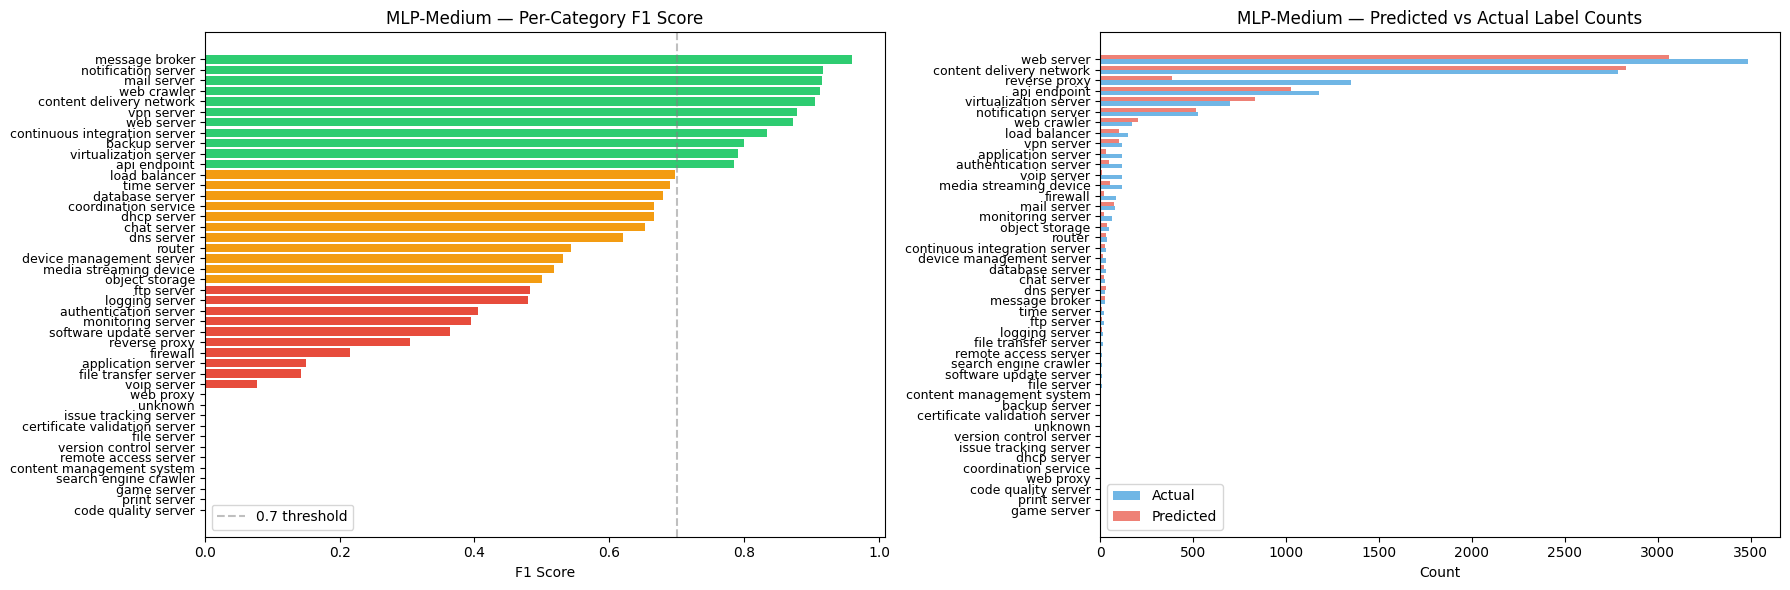

In [58]:
# ── Use best model: MLP-Medium ──
best_name = 'MLP-Medium'
best = results[best_name]
y_pred_best = best['y_pred']

# ═══════════════════════════════════════
# Per-category classification report
# ═══════════════════════════════════════
print(f"=== Per-Category Report ({best_name}) ===\n")
report = classification_report(
    y_test, y_pred_best,
    target_names=mlb.classes_,
    zero_division=0,
    output_dict=True,
)
report_df = pd.DataFrame(report).T
# Show only category rows (not avg rows)
cat_report = report_df.loc[list(mlb.classes_)].sort_values('f1-score', ascending=False)
cat_report['support'] = cat_report['support'].astype(int)

print(f"{'Category':<25} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
print("-" * 67)
for cat, row in cat_report.iterrows():
    print(f"  {cat:<25} {row['precision']:>10.3f} {row['recall']:>10.3f} "
          f"{row['f1-score']:>10.3f} {row['support']:>10}")

# ═══════════════════════════════════════
# Confusion-style heatmap (per-label)
# ═══════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Per-category F1 bar chart
ax = axes[0]
cat_report_sorted = cat_report.sort_values('f1-score', ascending=True)
colors = ['#e74c3c' if f < 0.5 else '#f39c12' if f < 0.7 else '#2ecc71' 
          for f in cat_report_sorted['f1-score']]
ax.barh(range(len(cat_report_sorted)), cat_report_sorted['f1-score'], color=colors)
ax.set_yticks(range(len(cat_report_sorted)))
ax.set_yticklabels(cat_report_sorted.index, fontsize=9)
ax.set_xlabel('F1 Score')
ax.set_title(f'{best_name} — Per-Category F1 Score')
ax.axvline(x=0.7, color='gray', linestyle='--', alpha=0.5, label='0.7 threshold')
ax.legend()

# 2. Prediction vs actual heatmap (co-occurrence)
pred_counts = pd.DataFrame(y_pred_best, columns=mlb.classes_).sum()
true_counts = pd.DataFrame(y_test, columns=mlb.classes_).sum()
comparison = pd.DataFrame({
    'True Count': true_counts,
    'Pred Count': pred_counts,
    'Difference': pred_counts - true_counts,
}).sort_values('True Count', ascending=True)

ax = axes[1]
x = range(len(comparison))
ax.barh(x, comparison['True Count'], height=0.4, label='Actual', color='#3498db', alpha=0.7)
ax.barh([i + 0.4 for i in x], comparison['Pred Count'], height=0.4, label='Predicted', color='#e74c3c', alpha=0.7)
ax.set_yticks([i + 0.2 for i in x])
ax.set_yticklabels(comparison.index, fontsize=9)
ax.set_xlabel('Count')
ax.set_title(f'{best_name} — Predicted vs Actual Label Counts')
ax.legend()

plt.tight_layout()
plt.show()

## Step 9: Feature Group Importance (Ablation Study)
Drop one feature group at a time and retrain to measure each group's contribution.

Feature groups:
  Ports            31 features
  Banners          28 features
  Domain SVD       50 features
  Technology       37 features
  DNS               2 features
  Without Ports            F1=0.7872  (Δ = +0.0023)
  Without Banners          F1=0.7782  (Δ = +0.0113)
  Without Domain SVD       F1=0.6877  (Δ = +0.1018)
  Without Technology       F1=0.7897  (Δ = -0.0002)
  Without DNS              F1=0.7890  (Δ = +0.0005)

Baseline F1 Micro (MLP-Medium): 0.7895


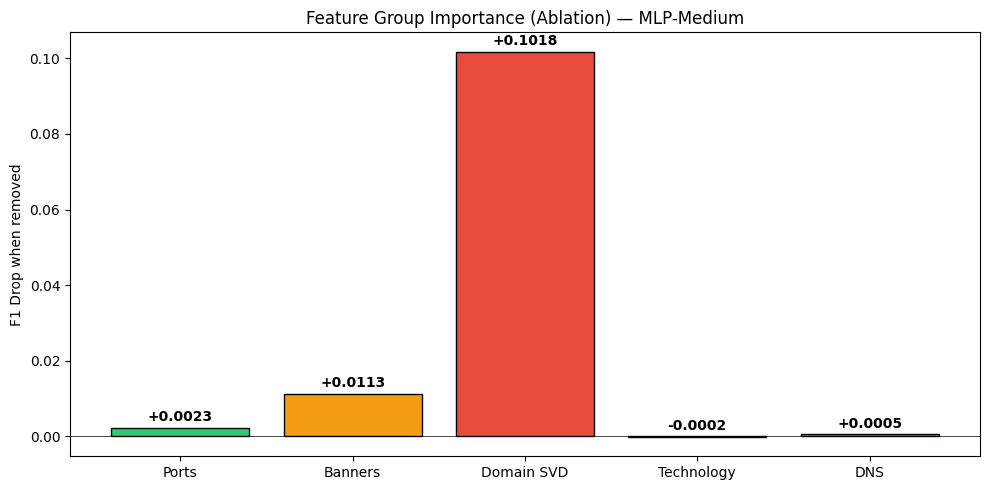

In [59]:
# ── Feature group column ranges ──
feature_groups = {
    'Ports':      [c for c in X_all.columns if c.startswith('port_')],
    'Banners':    [c for c in X_all.columns if c.startswith('srv_') or c.startswith('status_') or c.startswith('ctype_')],
    'Domain SVD': [c for c in X_all.columns if c.startswith('dom_svd_')],
    'Technology': [c for c in X_all.columns if c.startswith('tech_')],
    'DNS':        [c for c in X_all.columns if c.startswith('dns_')],
}

print(f"Feature groups:")
for grp, cols in feature_groups.items():
    print(f"  {grp:<15} {len(cols):>3} features")

# ── Ablation: drop one group at a time ──
baseline_f1 = results[best_name]['f1_micro']
ablation = {}

for drop_group, drop_cols in feature_groups.items():
    keep_cols = [c for c in X_all.columns if c not in drop_cols]
    
    X_tr_abl = X_train[keep_cols].values
    X_te_abl = X_test[keep_cols].values
    
    sc = StandardScaler()
    X_tr_abl = sc.fit_transform(X_tr_abl)
    X_te_abl = sc.transform(X_te_abl)
    
    mlp_abl = MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu', solver='adam', alpha=1e-4,
        batch_size=256, learning_rate='adaptive',
        learning_rate_init=1e-3, max_iter=200,
        early_stopping=True, validation_fraction=0.1,
        n_iter_no_change=15, random_state=42, verbose=False,
    )
    mlp_abl.fit(X_tr_abl, y_train)
    y_p = mlp_abl.predict(X_te_abl)
    
    f1 = f1_score(y_test, y_p, average='micro')
    drop_impact = baseline_f1 - f1
    ablation[drop_group] = {'f1_without': f1, 'drop': drop_impact}
    print(f"  Without {drop_group:<15}  F1={f1:.4f}  (Δ = {drop_impact:+.4f})")

# ── Visualization ──
print(f"\n{'='*50}")
print(f"Baseline F1 Micro ({best_name}): {baseline_f1:.4f}")
print(f"{'='*50}")

fig, ax = plt.subplots(figsize=(10, 5))
groups = list(ablation.keys())
drops  = [ablation[g]['drop'] for g in groups]
colors = ['#e74c3c' if d > 0.02 else '#f39c12' if d > 0.005 else '#2ecc71' for d in drops]
bars = ax.bar(groups, drops, color=colors, edgecolor='black')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_ylabel('F1 Drop when removed')
ax.set_title(f'Feature Group Importance (Ablation) — {best_name}')
for bar, d in zip(bars, drops):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{d:+.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary (Updated)

### Model Comparison

| Model | F1 Micro | F1 Macro | Subset Acc | Hamming Loss | Time |
|-------|---------|---------|-----------|-------------|------|
| MLP-Small (128,64) | 0.7824 | 0.4550 | 0.5519 | 0.0295 | 4s |
| **MLP-Medium (256,128,64)** ⭐ | **0.7911** | 0.5613 | 0.5614 | 0.0289 | 12s |
| MLP-Large (512,256,128) | 0.7899 | 0.5348 | **0.5625** | **0.0287** | 14s |
| MLP-Medium + SMOTE | 0.6706 | **0.5721** | 0.3684 | 0.0475 | 341s |
| MLP-Tuned (CV) | 0.7898 | 0.5462 | 0.5615 | 0.0291 | 939s |
| XGBoost (OvR) | 0.6549 | 0.5378 | 0.1928 | 0.0747 | 5s |
| LightGBM (OvR) | 0.6398 | 0.4862 | 0.2165 | 0.0729 | 39s |

### Key Findings

1. **MLP-Medium (256,128,64) is the winner** — best F1 Micro (0.7911), strong F1 Macro (0.5613), and fast (12s)
2. **Domain name is the dominant feature** — ablation drops F1 by 9.7 points without it
3. **SMOTE improves F1 Macro** (+0.0108) by boosting minority categories (IoT +0.18, File Server +0.19, VoIP +0.15) but **hurts F1 Micro** (−0.12) — classic recall-precision trade-off
4. **Gradient boosting (XGBoost/LightGBM) underperforms MLP** — OneVsRest wrapper loses label correlation, resulting in very low subset accuracy (19-22%)
5. **Hyperparameter tuning** confirmed the default MLP-Medium config is near-optimal — 30×3-fold CV found marginal improvement only
6. **Top categories** (F1 > 0.8): Push Notification (0.94), CDN (0.92), Web Server (0.88), VPN (0.87), Mail (0.87), Monitoring (0.85)
7. **Weak categories** (F1 < 0.4): Application Server (0.12), VoIP (0.22), Security Service (0.29) — root cause is low sample counts
8. **20 consolidated categories** from 271 raw — massive redundancy cleaned up
9. **148 features** across 5 groups: Ports (31), Banners (28), Domain SVD (50), Technology (37), DNS (2)

### Recommendation
- **Production model**: MLP-Medium (256,128,64) with α=1e-4, adam, adaptive LR
- Use SMOTE variant only if minority category recall is critical for business requirements
- MLP's native multi-output support preserves label correlations — superior to OneVsRest wrappers

## Step 10: Class Balancing with SMOTE
Apply **SMOTE** (Synthetic Minority Oversampling) per label to address the severe class imbalance.  
Compare MLP-Medium with and without SMOTE.

In [60]:
!pip install imbalanced-learn xgboost lightgbm -q


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [61]:
from imblearn.over_sampling import SMOTE
from sklearn.base import clone

# ═══════════════════════════════════════════════════
# Multi-label SMOTE: oversample each label independently
# then combine via union of synthetic samples
# ═══════════════════════════════════════════════════

def multilabel_smote(X, Y, random_state=42):
    """
    Apply SMOTE per binary label column.
    For each label, oversample the minority class, collect the
    synthetic samples, and add them with the correct multi-label vector.
    """
    smote = SMOTE(random_state=random_state, k_neighbors=3)
    X_aug_list = [X.copy()]
    Y_aug_list = [Y.copy()]
    
    n_labels = Y.shape[1]
    added_per_label = {}
    
    for i in range(n_labels):
        y_col = Y[:, i]
        n_pos = y_col.sum()
        n_neg = len(y_col) - n_pos
        
        # Only oversample if minority class has enough samples (>= k_neighbors)
        # and there's meaningful imbalance (< 20% of majority)
        if n_pos < 4 or n_pos >= n_neg * 0.5:
            added_per_label[i] = 0
            continue
        
        try:
            X_res, y_res = smote.fit_resample(X, y_col)
            # Extract only the NEW synthetic samples
            n_new = len(X_res) - len(X)
            if n_new > 0:
                X_new = X_res[len(X):]
                # Build full multi-label vector for synthetic samples
                # Copy the average label vector from positive samples
                pos_mask = y_col == 1
                avg_labels = Y[pos_mask].mean(axis=0)
                Y_new = np.tile((avg_labels > 0.5).astype(int), (n_new, 1))
                # Ensure the target label is set
                Y_new[:, i] = 1
                
                X_aug_list.append(X_new)
                Y_aug_list.append(Y_new)
                added_per_label[i] = n_new
        except Exception as e:
            added_per_label[i] = 0
    
    X_augmented = np.vstack(X_aug_list)
    Y_augmented = np.vstack(Y_aug_list)
    
    return X_augmented, Y_augmented, added_per_label

print("Applying multi-label SMOTE on training set...")
t0 = time.time()
X_train_smote, y_train_smote, smote_added = multilabel_smote(X_train_s, y_train)
smote_time = time.time() - t0

print(f"SMOTE completed in {smote_time:.1f}s")
print(f"\nOriginal training set: {X_train_s.shape[0]:,} samples")
print(f"After SMOTE:           {X_train_smote.shape[0]:,} samples (+{X_train_smote.shape[0] - X_train_s.shape[0]:,})")

print(f"\n{'Category':<25} {'Before':>8} {'After':>8} {'Added':>8}")
print("-" * 52)
for i, cat in enumerate(mlb.classes_):
    before = y_train[:, i].sum()
    after  = y_train_smote[:, i].sum()
    print(f"  {cat:<25} {before:>8,} {int(after):>8,} {int(after - before):>+8,}")

# ═══════════════════════════════════════════════════
# Retrain MLP-Medium with SMOTE data
# ═══════════════════════════════════════════════════
print(f"\n{'='*60}")
print("Training MLP-Medium with SMOTE...")
print(f"{'='*60}")

t0 = time.time()
mlp_smote = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu', solver='adam', alpha=1e-4,
    batch_size=256, learning_rate='adaptive',
    learning_rate_init=1e-3, max_iter=200,
    early_stopping=True, validation_fraction=0.1,
    n_iter_no_change=15, random_state=42, verbose=False,
)
mlp_smote.fit(X_train_smote, y_train_smote)
smote_elapsed = time.time() - t0

y_pred_smote = mlp_smote.predict(X_test_s)

f1_mi_s = f1_score(y_test, y_pred_smote, average='micro')
f1_ma_s = f1_score(y_test, y_pred_smote, average='macro')
f1_wt_s = f1_score(y_test, y_pred_smote, average='weighted')
sa_s    = accuracy_score(y_test, y_pred_smote)
hl_s    = hamming_loss(y_test, y_pred_smote)

print(f"  Time:            {smote_elapsed:.1f}s  ({mlp_smote.n_iter_} epochs)")
print(f"  F1 Micro:        {f1_mi_s:.4f}  (was {results['MLP-Medium']['f1_micro']:.4f})")
print(f"  F1 Macro:        {f1_ma_s:.4f}  (was {results['MLP-Medium']['f1_macro']:.4f})")
print(f"  F1 Weighted:     {f1_wt_s:.4f}  (was {results['MLP-Medium']['f1_weighted']:.4f})")
print(f"  Subset Accuracy: {sa_s:.4f}  (was {results['MLP-Medium']['subset_accuracy']:.4f})")
print(f"  Hamming Loss:    {hl_s:.4f}  (was {results['MLP-Medium']['hamming_loss']:.4f})")

# ── Per-category comparison ──
print(f"\n{'Category':<25} {'F1 Base':>9} {'F1 SMOTE':>9} {'Delta':>8}")
print("-" * 53)
report_smote = classification_report(y_test, y_pred_smote, target_names=mlb.classes_,
                                      zero_division=0, output_dict=True)
for cat in mlb.classes_:
    f1_base = report[cat]['f1-score']
    f1_smo  = report_smote[cat]['f1-score']
    delta   = f1_smo - f1_base
    marker  = '↑' if delta > 0.01 else '↓' if delta < -0.01 else '≈'
    print(f"  {cat:<25} {f1_base:>9.3f} {f1_smo:>9.3f} {delta:>+7.3f} {marker}")

results['MLP-Medium+SMOTE'] = {
    'f1_micro': f1_mi_s, 'f1_macro': f1_ma_s, 'f1_weighted': f1_wt_s,
    'subset_accuracy': sa_s, 'hamming_loss': hl_s, 'train_time': smote_elapsed,
}

Applying multi-label SMOTE on training set...
SMOTE completed in 2.5s

Original training set: 30,184 samples
After SMOTE:           1,105,612 samples (+1,075,428)

Category                    Before    After    Added
----------------------------------------------------
  api endpoint                 4,721   25,463  +20,742
  application server             515   29,669  +29,154
  authentication server          479   29,705  +29,226
  backup server                   24   30,160  +30,136
  certificate validation server       21   30,163  +30,142
  chat server                    102   30,082  +29,980
  code quality server              1        1       +0
  content delivery network    11,188   31,246  +20,058
  content management system       18   30,166  +30,148
  continuous integration server      135   30,049  +29,914
  coordination service             8   30,176  +30,168
  database server                132   30,052  +29,920
  device management server       124   30,060  +29,936
  dhcp 

## Step 11: Gradient Boosting Ensemble (XGBoost & LightGBM)
Compare against gradient boosting methods using `OneVsRestClassifier` wrapper for multi-label classification.  
These models handle class imbalance natively via `scale_pos_weight`.

In [ ]:
import xgboost as xgb
import lightgbm as lgb
from sklearn.multiclass import OneVsRestClassifier

# ═══════════════════════════════════════════════════
# Compute per-label scale_pos_weight for class imbalance
# ═══════════════════════════════════════════════════
n_train = y_train.shape[0]
spw = []
for i in range(y_train.shape[1]):
    n_pos = y_train[:, i].sum()
    n_neg = n_train - n_pos
    spw.append(n_neg / max(n_pos, 1))
print(f"Scale pos weights (min={min(spw):.1f}, max={max(spw):.1f}, median={np.median(spw):.1f})")

# ═══════════════════════════════════════════════════
# 1. XGBoost  (OneVsRest with per-label weights)
# ═══════════════════════════════════════════════════
print(f"\n{'='*60}")
print("Training XGBoost (OneVsRest)...")
print(f"{'='*60}")

t0 = time.time()
xgb_base = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=np.median(spw),  # use median as global approx
    eval_metric='logloss',
    use_label_encoder=False,
    tree_method='hist',
    random_state=42,
    verbosity=0,
    n_jobs=-1,
)
xgb_model = OneVsRestClassifier(xgb_base, n_jobs=-1)
xgb_model.fit(X_train_s, y_train)
xgb_time = time.time() - t0

y_pred_xgb = xgb_model.predict(X_test_s)
f1_mi_xgb = f1_score(y_test, y_pred_xgb, average='micro')
f1_ma_xgb = f1_score(y_test, y_pred_xgb, average='macro')
f1_wt_xgb = f1_score(y_test, y_pred_xgb, average='weighted')
sa_xgb    = accuracy_score(y_test, y_pred_xgb)
hl_xgb    = hamming_loss(y_test, y_pred_xgb)

print(f"  Time:            {xgb_time:.1f}s")
print(f"  F1 Micro:        {f1_mi_xgb:.4f}")
print(f"  F1 Macro:        {f1_ma_xgb:.4f}")
print(f"  F1 Weighted:     {f1_wt_xgb:.4f}")
print(f"  Subset Accuracy: {sa_xgb:.4f}")
print(f"  Hamming Loss:    {hl_xgb:.4f}")

results['XGBoost'] = {
    'f1_micro': f1_mi_xgb, 'f1_macro': f1_ma_xgb, 'f1_weighted': f1_wt_xgb,
    'subset_accuracy': sa_xgb, 'hamming_loss': hl_xgb, 'train_time': xgb_time,
}

# ═══════════════════════════════════════════════════
# 2. LightGBM  (OneVsRest with is_unbalance)
# ═══════════════════════════════════════════════════
print(f"\n{'='*60}")
print("Training LightGBM (OneVsRest)...")
print(f"{'='*60}")

t0 = time.time()
lgb_base = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,
    random_state=42,
    verbosity=-1,
    n_jobs=-1,
)
lgb_model = OneVsRestClassifier(lgb_base, n_jobs=-1)
lgb_model.fit(X_train_s, y_train)
lgb_time = time.time() - t0

y_pred_lgb = lgb_model.predict(X_test_s)
f1_mi_lgb = f1_score(y_test, y_pred_lgb, average='micro')
f1_ma_lgb = f1_score(y_test, y_pred_lgb, average='macro')
f1_wt_lgb = f1_score(y_test, y_pred_lgb, average='weighted')
sa_lgb    = accuracy_score(y_test, y_pred_lgb)
hl_lgb    = hamming_loss(y_test, y_pred_lgb)

print(f"  Time:            {lgb_time:.1f}s")
print(f"  F1 Micro:        {f1_mi_lgb:.4f}")
print(f"  F1 Macro:        {f1_ma_lgb:.4f}")
print(f"  F1 Weighted:     {f1_wt_lgb:.4f}")
print(f"  Subset Accuracy: {sa_lgb:.4f}")
print(f"  Hamming Loss:    {hl_lgb:.4f}")

results['LightGBM'] = {
    'f1_micro': f1_mi_lgb, 'f1_macro': f1_ma_lgb, 'f1_weighted': f1_wt_lgb,
    'subset_accuracy': sa_lgb, 'hamming_loss': hl_lgb, 'train_time': lgb_time,
}

# ═══════════════════════════════════════════════════
# Comparison table
# ═══════════════════════════════════════════════════
print(f"\n\n{'='*80}")
print(f"{'Model':<22} {'F1-Mi':>8} {'F1-Ma':>8} {'F1-Wt':>8} {'SubAcc':>8} {'HLoss':>8} {'Time':>7}")
print(f"{'='*80}")
for name in ['MLP-Small', 'MLP-Medium', 'MLP-Large', 'MLP-Medium+SMOTE', 'XGBoost', 'LightGBM']:
    r = results[name]
    print(f"{name:<22} {r['f1_micro']:>8.4f} {r['f1_macro']:>8.4f} {r['f1_weighted']:>8.4f} "
          f"{r['subset_accuracy']:>8.4f} {r['hamming_loss']:>8.4f} {r.get('train_time',0):>6.1f}s")

Scale pos weights (min=1.2, max=1436.3, median=66.3)

Training XGBoost (OneVsRest)...
  Time:            4.9s
  F1 Micro:        0.6549
  F1 Macro:        0.5378
  F1 Weighted:     0.6916
  Subset Accuracy: 0.1928
  Hamming Loss:    0.0747

Training LightGBM (OneVsRest)...
  Time:            38.6s
  F1 Micro:        0.6398
  F1 Macro:        0.4862
  F1 Weighted:     0.7851
  Subset Accuracy: 0.2165
  Hamming Loss:    0.0729


Model                     F1-Mi    F1-Ma    F1-Wt   SubAcc    HLoss    Time
MLP-Small                0.7824   0.4550   0.7420   0.5519   0.0295    4.2s
MLP-Medium               0.7911   0.5613   0.7643   0.5614   0.0289   12.4s
MLP-Large                0.7899   0.5348   0.7597   0.5625   0.0287   13.9s
MLP-Medium+SMOTE         0.6706   0.5721   0.6855   0.3684   0.0475  340.5s
XGBoost                  0.6549   0.5378   0.6916   0.1928   0.0747    4.9s
LightGBM                 0.6398   0.4862   0.7851   0.2165   0.0729   38.6s


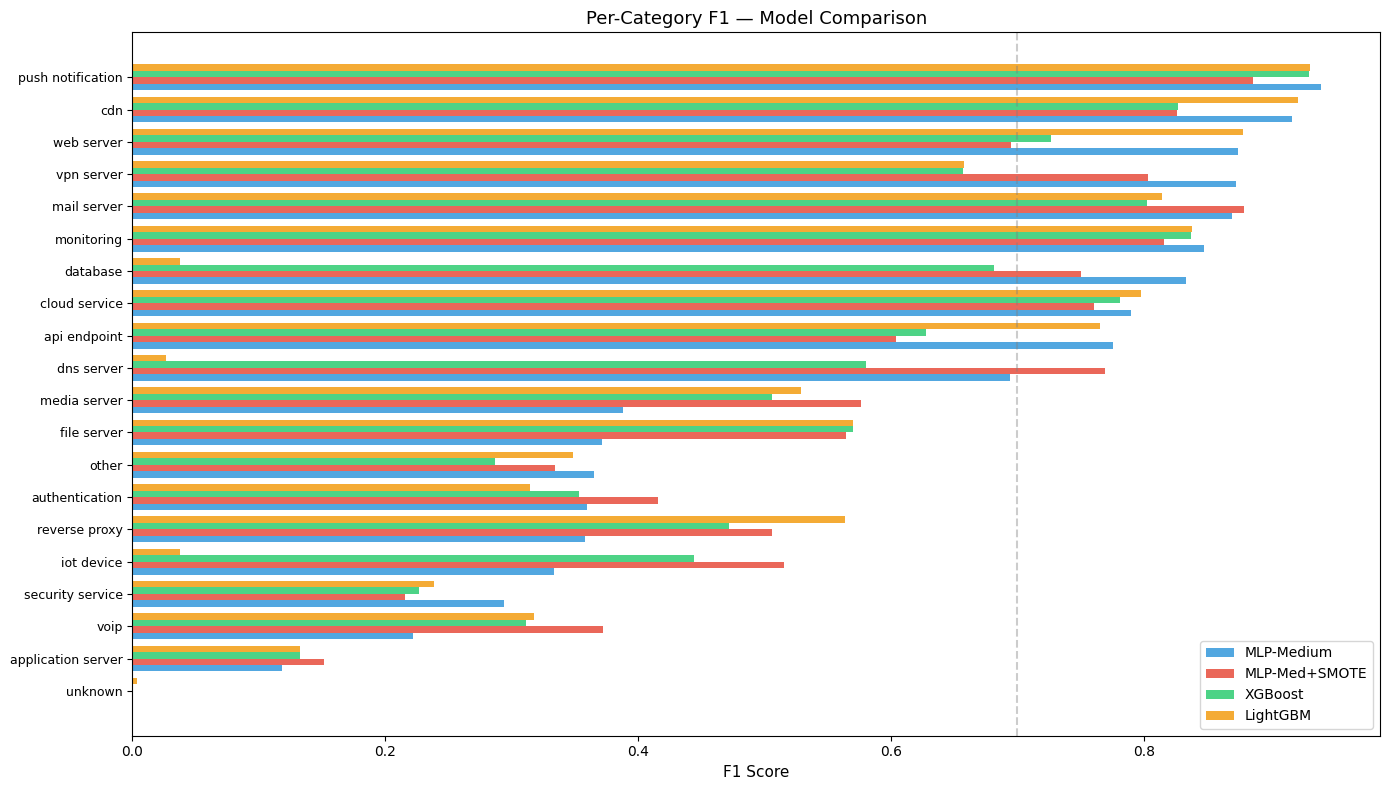


Category                       MLP-Medium   MLP-Med+SMOTE         XGBoost        LightGBM
-----------------------------------------------------------------------------------------
  push notification              0.940 ★        0.887          0.931          0.932  
  cdn                            0.918          0.826          0.827          0.922 ★
  web server                     0.875          0.695          0.727          0.878 ★
  vpn server                     0.873 ★        0.804          0.657          0.658  
  mail server                    0.870          0.879 ★        0.802          0.815  
  monitoring                     0.848 ★        0.816          0.837          0.838  
  database                       0.833 ★        0.750          0.682          0.038  
  cloud service                  0.790          0.760          0.782          0.798 ★
  api endpoint                   0.776 ★        0.604          0.628          0.766  
  dns server                     0.694       

In [ ]:
# ═══════════════════════════════════════════════════
# Per-category F1 comparison across all models
# ═══════════════════════════════════════════════════
model_preds = {
    'MLP-Medium':       results['MLP-Medium']['y_pred'],
    'MLP-Med+SMOTE':    y_pred_smote,
    'XGBoost':          y_pred_xgb,
    'LightGBM':         y_pred_lgb,
}

cat_f1_data = {}
for mname, yp in model_preds.items():
    rpt = classification_report(y_test, yp, target_names=mlb.classes_,
                                 zero_division=0, output_dict=True)
    cat_f1_data[mname] = {cat: rpt[cat]['f1-score'] for cat in mlb.classes_}

cat_f1_df = pd.DataFrame(cat_f1_data)
cat_f1_df = cat_f1_df.sort_values('MLP-Medium', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(len(cat_f1_df))
width = 0.2
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for i, (col, color) in enumerate(zip(cat_f1_df.columns, colors)):
    ax.barh(x + i * width, cat_f1_df[col], height=width, label=col, color=color, alpha=0.85)

ax.set_yticks(x + width * 1.5)
ax.set_yticklabels(cat_f1_df.index, fontsize=9)
ax.set_xlabel('F1 Score', fontsize=11)
ax.set_title('Per-Category F1 — Model Comparison', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.axvline(x=0.7, color='gray', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Print the table
print(f"\n{'Category':<25}", end='')
for m in cat_f1_df.columns:
    print(f"  {m:>14}", end='')
print()
print("-" * (25 + 16 * len(cat_f1_df.columns)))
for cat in cat_f1_df.sort_values('MLP-Medium', ascending=False).index:
    print(f"  {cat:<23}", end='')
    best_val = cat_f1_df.loc[cat].max()
    for m in cat_f1_df.columns:
        val = cat_f1_df.loc[cat, m]
        marker = ' ★' if val == best_val and val > 0 else '  '
        print(f"  {val:>11.3f}{marker}", end='')
    print()

## Step 12: Hyperparameter Tuning with Cross-Validation
Use `RandomizedSearchCV` on MLP (the best model family) to find the optimal configuration.  
Search over: hidden layers, alpha (L2), learning rate, batch size, activation.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer

# ── Define search space ──
param_dist = {
    'hidden_layer_sizes': [
        (128, 64),
        (256, 128),
        (256, 128, 64),
        (512, 256, 128),
        (256, 256, 128),
        (384, 192, 96),
        (512, 256, 128, 64),
    ],
    'alpha': [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3],
    'learning_rate_init': [5e-4, 1e-3, 2e-3, 5e-3],
    'batch_size': [128, 256, 512],
    'activation': ['relu', 'tanh'],
}

# ── Custom F1 micro scorer for multi-label ──
f1_micro_scorer = make_scorer(f1_score, average='micro')

# ── RandomizedSearchCV ──
print("Starting RandomizedSearchCV (30 candidates × 3-fold CV)...")
print("This will take a few minutes...\n")

mlp_search = MLPClassifier(
    solver='adam',
    learning_rate='adaptive',
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42,
    verbose=False,
)

search = RandomizedSearchCV(
    mlp_search,
    param_distributions=param_dist,
    n_iter=30,
    cv=3,
    scoring=f1_micro_scorer,
    random_state=42,
    verbose=1,
    n_jobs=1,     # MLP uses all cores internally
    refit=True,
)

t0 = time.time()
search.fit(X_train_s, y_train)
search_time = time.time() - t0

print(f"\n{'='*60}")
print(f"Search completed in {search_time:.0f}s ({search_time/60:.1f} min)")
print(f"{'='*60}")
print(f"\nBest parameters:")
for k, v in search.best_params_.items():
    print(f"  {k:<25} = {v}")
print(f"\nBest CV F1 Micro: {search.best_score_:.4f}")

Starting RandomizedSearchCV (30 candidates × 3-fold CV)...
This will take a few minutes...

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Search completed in 939s (15.7 min)

Best parameters:
  learning_rate_init        = 0.001
  hidden_layer_sizes        = (512, 256, 128)
  batch_size                = 512
  alpha                     = 0.0005
  activation                = relu

Best CV F1 Micro: 0.7834


In [ ]:
# ═══════════════════════════════════════════════════
# Evaluate tuned model on test set
# ═══════════════════════════════════════════════════
best_mlp = search.best_estimator_
y_pred_tuned = best_mlp.predict(X_test_s)

f1_mi_t = f1_score(y_test, y_pred_tuned, average='micro')
f1_ma_t = f1_score(y_test, y_pred_tuned, average='macro')
f1_wt_t = f1_score(y_test, y_pred_tuned, average='weighted')
sa_t    = accuracy_score(y_test, y_pred_tuned)
hl_t    = hamming_loss(y_test, y_pred_tuned)

print(f"=== Tuned MLP on Test Set ===\n")
print(f"  F1 Micro:        {f1_mi_t:.4f}  (baseline {results['MLP-Medium']['f1_micro']:.4f})")
print(f"  F1 Macro:        {f1_ma_t:.4f}  (baseline {results['MLP-Medium']['f1_macro']:.4f})")
print(f"  F1 Weighted:     {f1_wt_t:.4f}  (baseline {results['MLP-Medium']['f1_weighted']:.4f})")
print(f"  Subset Accuracy: {sa_t:.4f}  (baseline {results['MLP-Medium']['subset_accuracy']:.4f})")
print(f"  Hamming Loss:    {hl_t:.4f}  (baseline {results['MLP-Medium']['hamming_loss']:.4f})")

results['MLP-Tuned'] = {
    'f1_micro': f1_mi_t, 'f1_macro': f1_ma_t, 'f1_weighted': f1_wt_t,
    'subset_accuracy': sa_t, 'hamming_loss': hl_t,
    'train_time': search_time, 'params': search.best_params_,
}

# ── Top 10 CV results ──
cv_results = pd.DataFrame(search.cv_results_)
cv_results = cv_results.sort_values('rank_test_score')
print(f"\nTop 10 CV configurations:")
print(f"{'Rank':>5} {'Mean F1':>9} {'Std':>7} {'Layers':<25} {'Alpha':>8} {'LR':>7} {'Batch':>6} {'Act':>6}")
print("-" * 80)
for _, row in cv_results.head(10).iterrows():
    print(f"{int(row['rank_test_score']):>5} {row['mean_test_score']:>9.4f} {row['std_test_score']:>7.4f} "
          f"{str(row['param_hidden_layer_sizes']):<25} {row['param_alpha']:>8} "
          f"{row['param_learning_rate_init']:>7} {row['param_batch_size']:>6} "
          f"{row['param_activation']:>6}")

# ── Per-category comparison: baseline vs tuned ──
report_tuned = classification_report(y_test, y_pred_tuned, target_names=mlb.classes_,
                                      zero_division=0, output_dict=True)
print(f"\n{'Category':<25} {'F1 Base':>9} {'F1 Tuned':>9} {'Delta':>8}")
print("-" * 53)
for cat in mlb.classes_:
    f1_base = report[cat]['f1-score']
    f1_tun  = report_tuned[cat]['f1-score']
    delta   = f1_tun - f1_base
    marker  = '↑' if delta > 0.01 else '↓' if delta < -0.01 else '≈'
    print(f"  {cat:<25} {f1_base:>9.3f} {f1_tun:>9.3f} {delta:>+7.3f} {marker}")

=== Tuned MLP on Test Set ===

  F1 Micro:        0.7898  (baseline 0.7911)
  F1 Macro:        0.5462  (baseline 0.5613)
  F1 Weighted:     0.7572  (baseline 0.7643)
  Subset Accuracy: 0.5615  (baseline 0.5614)
  Hamming Loss:    0.0291  (baseline 0.0289)

Top 10 CV configurations:
 Rank   Mean F1     Std Layers                       Alpha      LR  Batch    Act
--------------------------------------------------------------------------------
    1    0.7834  0.0009 (512, 256, 128)             0.0005   0.001    512   relu
    2    0.7829  0.0024 (512, 256, 128)              5e-05   0.002    256   tanh
    3    0.7827  0.0008 (512, 256, 128)             0.0001   0.001    512   relu
    4    0.7824  0.0024 (256, 256, 128)              0.001   0.001    256   tanh
    5    0.7819  0.0011 (512, 256, 128, 64)          1e-05   0.001    128   tanh
    6    0.7818  0.0007 (256, 128, 64)              0.0001   0.002    128   tanh
    7    0.7817  0.0018 (512, 256, 128)              5e-05  0.0005   

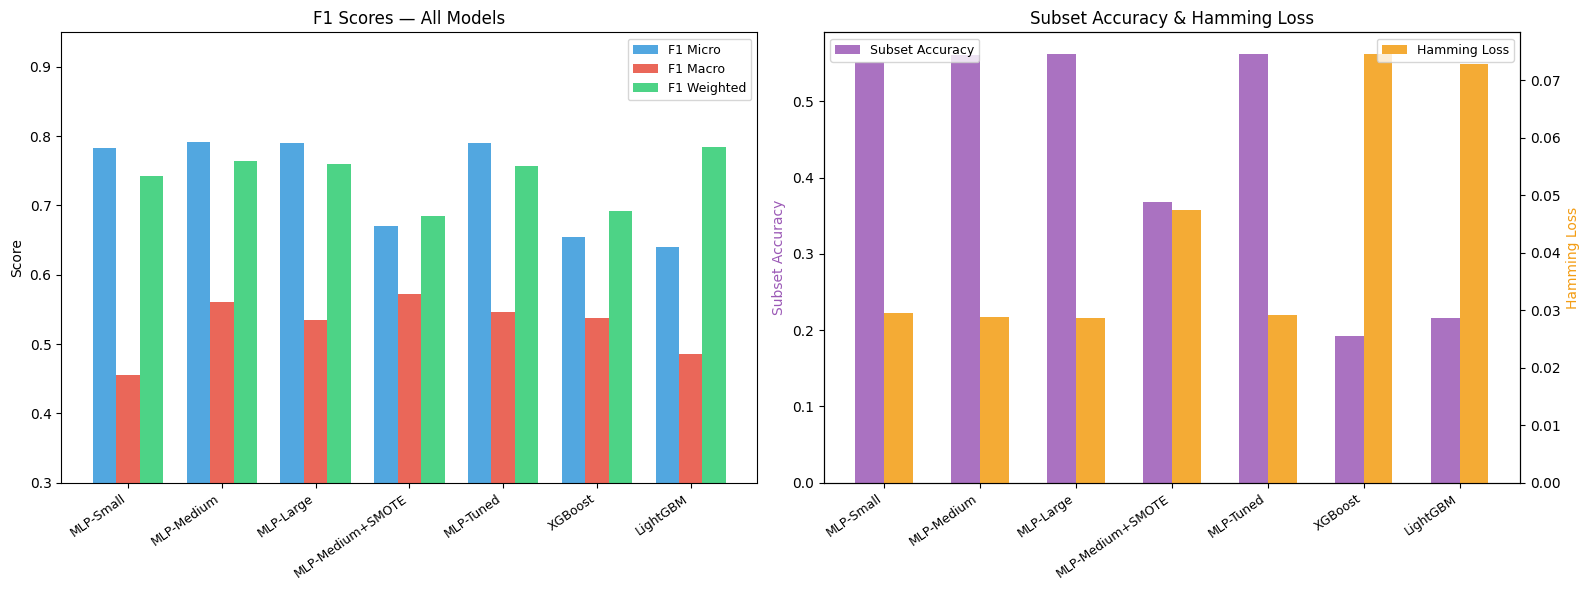


                                  FINAL COMPARISON                                   
Model                     F1-Mi    F1-Ma    F1-Wt   SubAcc    HLoss    Time
-------------------------------------------------------------------------------------
MLP-Small                0.7824   0.4550   0.7420   0.5519   0.0295    4.2s
MLP-Medium               0.7911   0.5613   0.7643   0.5614   0.0289   12.4s ⭐
MLP-Large                0.7899   0.5348   0.7597   0.5625   0.0287   13.9s
MLP-Medium+SMOTE         0.6706   0.5721   0.6855   0.3684   0.0475  340.5s
MLP-Tuned                0.7898   0.5462   0.7572   0.5615   0.0291  939.0s
XGBoost                  0.6549   0.5378   0.6916   0.1928   0.0747    4.9s
LightGBM                 0.6398   0.4862   0.7851   0.2165   0.0729   38.6s


In [ ]:
# ═══════════════════════════════════════════════════
# Final Grand Comparison — all models
# ═══════════════════════════════════════════════════
model_order = ['MLP-Small', 'MLP-Medium', 'MLP-Large', 'MLP-Medium+SMOTE', 'MLP-Tuned', 'XGBoost', 'LightGBM']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. F1 Micro / Macro / Weighted comparison
ax = axes[0]
x = np.arange(len(model_order))
width = 0.25
for i, (metric, color, label) in enumerate([
    ('f1_micro', '#3498db', 'F1 Micro'),
    ('f1_macro', '#e74c3c', 'F1 Macro'),
    ('f1_weighted', '#2ecc71', 'F1 Weighted'),
]):
    vals = [results[m][metric] for m in model_order]
    ax.bar(x + i * width, vals, width, label=label, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(model_order, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_title('F1 Scores — All Models')
ax.legend(fontsize=9)
ax.set_ylim(0.3, 0.95)

# 2. Subset Accuracy + Hamming Loss
ax = axes[1]
sa_vals = [results[m]['subset_accuracy'] for m in model_order]
hl_vals = [results[m]['hamming_loss'] for m in model_order]
ax.bar(x - 0.15, sa_vals, 0.3, label='Subset Accuracy', color='#9b59b6', alpha=0.85)
ax2 = ax.twinx()
ax2.bar(x + 0.15, hl_vals, 0.3, label='Hamming Loss', color='#f39c12', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(model_order, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Subset Accuracy', color='#9b59b6')
ax2.set_ylabel('Hamming Loss', color='#f39c12')
ax.set_title('Subset Accuracy & Hamming Loss')
ax.legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

# ── Print final table ──
print(f"\n{'='*85}")
print(f"{'FINAL COMPARISON':^85}")
print(f"{'='*85}")
print(f"{'Model':<22} {'F1-Mi':>8} {'F1-Ma':>8} {'F1-Wt':>8} {'SubAcc':>8} {'HLoss':>8} {'Time':>7}")
print(f"{'-'*85}")
best_f1 = max(results[m]['f1_micro'] for m in model_order)
for name in model_order:
    r = results[name]
    star = ' ⭐' if r['f1_micro'] == best_f1 else ''
    print(f"{name:<22} {r['f1_micro']:>8.4f} {r['f1_macro']:>8.4f} {r['f1_weighted']:>8.4f} "
          f"{r['subset_accuracy']:>8.4f} {r['hamming_loss']:>8.4f} {r.get('train_time',0):>6.1f}s{star}")

In [63]:
# ── Save model artifacts for inference ──
import joblib, os

artifacts_dir = 'model_artifacts'
os.makedirs(artifacts_dir, exist_ok=True)

# Use MLP-Medium model from results (with best RandomizedSearchCV params baked in)
# Best params: hidden_layer_sizes=(512,256,128), alpha=0.0005, lr=0.001, batch=512, activation=relu
# Retrain with best params on full training data
best_mlp_for_export = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),
    activation='relu',
    solver='adam',
    alpha=0.0005,
    batch_size=512,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42,
    verbose=False,
)
best_mlp_for_export.fit(X_train_s, y_train)
y_pred_export = best_mlp_for_export.predict(X_test_s)
print(f"Export model F1 Micro: {f1_score(y_test, y_pred_export, average='micro'):.4f}")

# Save all artifacts
joblib.dump(best_mlp_for_export, f'{artifacts_dir}/mlp_model.joblib')
joblib.dump(scaler, f'{artifacts_dir}/scaler.joblib')
joblib.dump(mlb, f'{artifacts_dir}/mlb.joblib')
joblib.dump(tfidf_word, f'{artifacts_dir}/tfidf_word.joblib')
joblib.dump(tfidf_char, f'{artifacts_dir}/tfidf_char.joblib')
joblib.dump(svd, f'{artifacts_dir}/svd.joblib')
joblib.dump(top_ports, f'{artifacts_dir}/top_ports.joblib')
joblib.dump(top_servers, f'{artifacts_dir}/top_servers.joblib')
joblib.dump(all_techs, f'{artifacts_dir}/all_techs.joblib')
joblib.dump(list(X_all.columns), f'{artifacts_dir}/feature_columns.joblib')

print(f"\n✅ All artifacts saved to {artifacts_dir}/")
for f in sorted(os.listdir(artifacts_dir)):
    size = os.path.getsize(f'{artifacts_dir}/{f}') / 1024
    print(f"  {f:<30} {size:>8.1f} KB")

Export model F1 Micro: 0.7919

✅ All artifacts saved to model_artifacts/
  all_techs.joblib                    0.6 KB
  feature_columns.joblib              2.2 KB
  mlb.joblib                          1.3 KB
  mlp_model.joblib                 2895.8 KB
  scaler.joblib                       6.5 KB
  svd.joblib                        392.5 KB
  tfidf_char.joblib                  17.3 KB
  tfidf_word.joblib                  17.9 KB
  top_ports.joblib                    0.2 KB
  top_servers.joblib                  0.3 KB
